# 16. Time Series Tools

:::{admonition} Course Website 
http://54.243.252.9/ce-5319-webroot/ 
:::

# 16.2 Time Series Modeling with Recurrent Neural Networks (RNNs)

## Why Use RNNs for Time Series?

Standard neural networks like feedforward networks or CNNs do not account for the order of input data. But in time series tasks — such as rainfall-runoff modeling, evapotranspiration forecasting, or streamflow prediction — temporal dependencies are crucial.

Recurrent Neural Networks (RNNs) are designed to handle sequences by maintaining a hidden state that captures information from previous time steps. This gives RNNs a form of memory, making them well-suited for:

- Hydrologic time series forecasting

- Climate anomaly detection

- Multi-step ahead streamflow prediction

## Core Architecture of RNNs
At each time step $t$, the RNN receives input $x_t$ and combines it with a hidden state $h_{t-1}$ from the previous time step:

$$h_t = \sigma(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$$

$$y_t = W_{hy}h_t +b_y$$


Here, $\sigma$ is usually a non-linear activation like tanh or ReLU.

## Challenges with Basic RNNs
- Vanishing gradients: Makes learning long-term dependencies difficult.
- Exploding gradients: Can lead to unstable training.

To overcome these, advanced RNN variants are used:

### Long Short-Term Memory (LSTM)
LSTM introduces gates that control the flow of information:

- Forget gate: Discards irrelevant past information.
- Input gate: Updates the memory with new data.
- Output gate: Decides what information to send forward.

This structure allows LSTMs to remember patterns over long durations — useful in hydrology where processes may have seasonal or delayed effects.

### Gated Recurrent Unit (GRU)
GRUs simplify LSTM by combining the forget and input gates into an update gate. They train faster and require fewer parameters, while still addressing the vanishing gradient problem.

Use GRU when:

- Training time is limited.
- You want a lighter model with comparable performance.

### Temporal Convolutional Neural Networks (TCNNs)
An alternative to RNNs, TCNNs use 1D convolutions across the time axis to extract temporal patterns. They offer:

- Parallel computation (unlike RNNs, which are sequential).

- Longer memory range using dilated convolutions.

When to prefer TCNNs:

- When interpretability is less critical.

- When modeling fixed-length time windows.

## Summary: RNNs vs. TCNNs

|Feature	|RNN / LSTM / GRU|	Temporal CNN (TCNN)|
|-----------|----------------|---------------------|
|Memory mechanism	|Hidden state, gating	|Convolutional filter memory|
|Sequence dependency	|Maintains order	|Captures with dilation|
|Computation style	|Sequential	|Parallelizable|
|Strengths	|Captures delayed effects	|Fast and scalable|

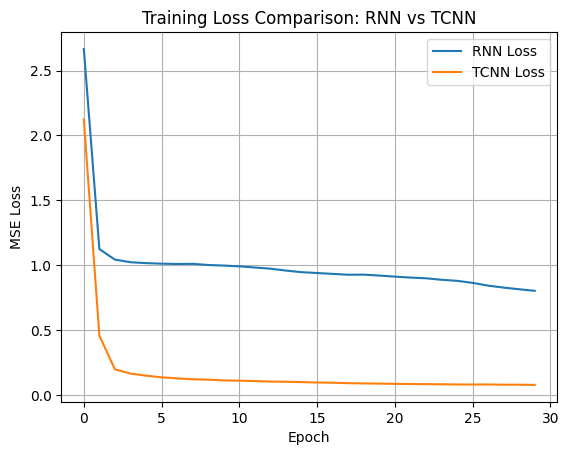

In [1]:
# RNN vs TCNN Example: Synthetic Runoff Forecasting
# Author: ChatGPT for Sensei's CE 5319 Course

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# --- Synthetic Data Generation ---
def generate_runoff_data(n_samples=500, time_steps=30):
    np.random.seed(42)
    rainfall = np.random.gamma(2.0, 2.0, size=(n_samples, time_steps))
    runoff = np.zeros_like(rainfall)
    for i in range(n_samples):
        for t in range(time_steps):
            delay = max(t - 2, 0)  # simple delay effect
            runoff[i, t] = 0.3 * rainfall[i, delay] + 0.05 * np.sum(rainfall[i, max(t-5, 0):t])
    return rainfall, runoff

# Prepare data
X, y = generate_runoff_data()
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # shape: (N, T, 1)
y = torch.tensor(y, dtype=torch.float32)
train_ds = TensorDataset(X, y)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

# --- RNN Model ---
class RNNForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, X.shape[1])

    def forward(self, x):
        _, h_n = self.rnn(x)  # output ignored, h_n is final hidden state
        out = self.fc(h_n.squeeze(0))
        return out

# --- TCNN Model ---
class TCNNForecast(nn.Module):
    def __init__(self, input_size=1, channels=16, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_size, channels, kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(channels, 1, kernel_size, padding=1)

    def forward(self, x):
        x = x.transpose(1, 2)  # to (batch, channel, seq)
        x = self.relu(self.conv1(x))
        x = self.conv2(x).squeeze(1)  # (batch, seq)
        return x

# --- Training Loop ---
def train_model(model, train_dl, epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    loss_history = []

    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history.append(total_loss / len(train_dl))
    return loss_history

# Instantiate and train both models
rnn_model = RNNForecast()
tcnn_model = TCNNForecast()
rnn_loss = train_model(rnn_model, train_dl)
tcnn_loss = train_model(tcnn_model, train_dl)

# --- Plot Training Loss ---
plt.plot(rnn_loss, label="RNN Loss")
plt.plot(tcnn_loss, label="TCNN Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Comparison: RNN vs TCNN")
plt.legend()
plt.grid(True)
plt.show()


## Relationship to Markov Chains
Recurrent Neural Networks (RNNs), especially LSTM and GRU, can be thought of as supersets or generalizations of Markov chains, particularly when considering sequence modeling. Here's how the comparison maps out:

### Markov Chain vs. RNN (LSTM/GRU)

![](MarkovGRU.png)

|Feature	|Markov Chain	|RNN (LSTM / GRU)|
|-----------|---------------|----------------|
|Memory Depth	|Typically 1-step (first-order), though higher-order Markov models exist	|Arbitrary length memory (learned through training)|
|State Representation	|Finite discrete states	|Continuous-valued hidden state vector|
|Transition Function	|Fixed transition probabilities	|Learned via optimization (backpropagation through time)|
|Nonlinearity	|Linear, probabilistic	|Highly nonlinear, uses activation functions|
|Data Type	|Symbolic / categorical	|Real-valued or categorical sequences|
|Training	|Count-based estimation or MLE	|Gradient-based learning (SGD/Adam)|

### What RNNs Add to Markov Logic
1. Learned Representations:

   RNNs don’t assume a fixed number of discrete states — they learn abstract representations dynamically based on input data.

3. Long-Term Dependencies:

   LSTMs and GRUs can remember patterns over hundreds of timesteps (something Markov models struggle with beyond a few steps).

5. Non-Markovian Dynamics:

   Because RNNs use learned gating mechanisms (like in GRUs/LSTMs), they can encode dependencies that aren't strictly step-to-step.

7. Rich Outputs:

   RNNs can generate real-valued outputs, probabilities, or categorical labels, making them applicable to a broader range of forecasting, translation, and classification problems.

### In Hydrology
A first-order Markov model might say:

> “Given today's rainfall, here’s the probability of tomorrow's runoff.”

A GRU or LSTM can model:

> “Given the past 30 days of rainfall, temperature, and soil saturation, predict runoff tomorrow — and update memory weights to get better over time.”



## Example: Markov Chain vs. GRU on the same synthetic data

In [ ]:
# Markov Chain vs GRU on Synthetic Runoff Data
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# --- Step 1: Generate synthetic rainfall and runoff data ---
def generate_data(n_samples=500, time_steps=30):
    np.random.seed(42)
    rainfall = np.random.gamma(2.0, 2.0, size=(n_samples, time_steps))
    runoff = np.zeros_like(rainfall)
    for i in range(n_samples):
        for t in range(time_steps):
            delay = max(t - 2, 0)
            runoff[i, t] = 0.3 * rainfall[i, delay] + 0.05 * np.sum(rainfall[i, max(t - 5, 0):t])
    return rainfall, runoff

X, y = generate_data()

# --- Step 2: Markov Model (1st-order) ---
def markov_predict(X):
    # Predict runoff at t using rainfall at t-1
    runoff_pred = np.zeros_like(X)
    for i in range(X.shape[0]):
        runoff_pred[i, 1:] = 0.3 * X[i, :-1]  # mimic the delay
    return runoff_pred

markov_pred = markov_predict(X)

# --- Step 3: GRU Model ---
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, X.shape[1])

    def forward(self, x):
        _, h_n = self.rnn(x)
        out = self.fc(h_n.squeeze(0))
        return out

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y_tensor = torch.tensor(y, dtype=torch.float32)
data = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(data, batch_size=32, shuffle=True)

model = GRUForecast()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(30):
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Predict using GRU
model.eval()
with torch.no_grad():
    gru_pred = model(X_tensor).numpy()

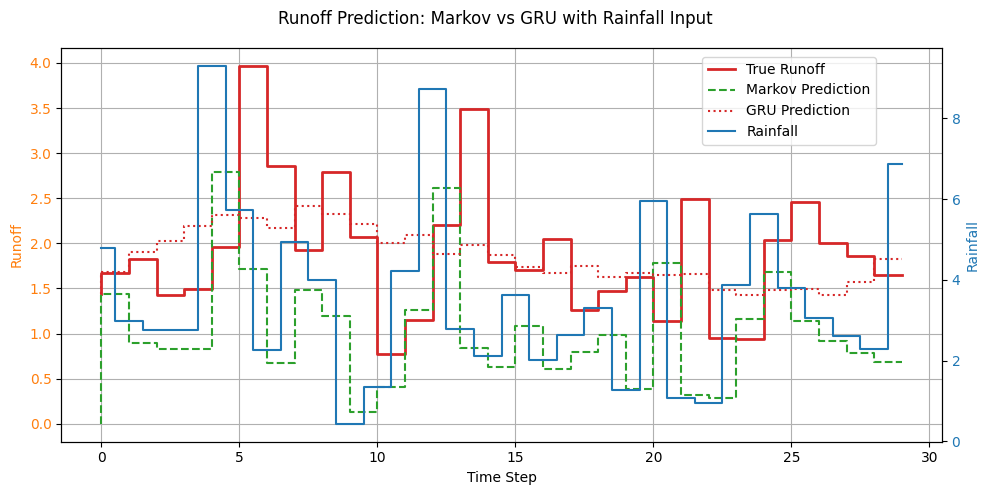

In [27]:
# --- Step 4: Compare predictions with dual y-axes ---
sample_idx = 0
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary y-axis for runoff
ax1.step(range(len(y[sample_idx])),y[sample_idx], label="True Runoff", linewidth=2, color='tab:red')
ax1.step(range(len(markov_pred[sample_idx])),markov_pred[sample_idx], label="Markov Prediction", linestyle='--', color='tab:green')
ax1.step(range(len(gru_pred[sample_idx])),gru_pred[sample_idx], label="GRU Prediction", linestyle=':', color='tab:red')
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Runoff", color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(True)

# Secondary y-axis for rainfall
ax2 = ax1.twinx()
ax2.step(range(len(X[sample_idx])), X[sample_idx], label="Rainfall", where='mid', color='tab:blue', linewidth=1.5)
ax2.set_ylabel("Rainfall", color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and legend
fig.suptitle("Runoff Prediction: Markov vs GRU with Rainfall Input", fontsize=12)
fig.legend(loc="upper left", bbox_to_anchor=(0.7, 0.9))
fig.tight_layout()
plt.show()
